# VIX futures Modelling using Heston-Nandi GARCH type processes

In [89]:
from models.two_component_GARCH import ComponentGARCH
from models.HNGARCH import HNGARCH
import numpy as np
import yfinance as yf
import datetime
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import random

random.seed(42)

daily_spx = pd.read_csv("data//SPX//daily_spx.csv")
daily_spx['Date'] = pd.to_datetime(daily_spx['Date'])
start_date = '2010-01-01'
end_date = '2018-12-31'
daily_spx = daily_spx[(daily_spx['Date']>= start_date)&(daily_spx['Date']<=end_date)]
log_returns = np.log(daily_spx['Adj Close'] / daily_spx['Adj Close'].shift(1)).values[1:]
z_scores = np.abs(zscore(log_returns))
log_returns[z_scores > 3] = np.nan  # Replace outliers with NaN (you can also drop or impute them)

# Impute missing values if any (forward fill or use mean/median)
for i in range(1, len(log_returns)):
    if np.isnan(log_returns[i]):
        log_returns[i] = log_returns[i-1]  # Forward fill# model.fit(log_returns[1:10])
mean_lr = np.mean(log_returns)
std_lr = np.std(log_returns)
normalized_log_returns = (log_returns- np.mean(log_returns))/std_lr
window_size = 10
cumulative_variance = pd.Series((log_returns**2).cumsum())
realized_variance = cumulative_variance - cumulative_variance.shift(window_size, fill_value=0)
realized_variance /= window_size

## Original Heston-Nandi GARCH (HNGARCH)

Under the physical measure ($\mathbf{P}$), we can assume the asset log returns $R_t$ follow
$$
R_{t+1} = \ln\left(\frac{S_{t+1}}{S_t}\right)=  r_{t+1} + \left(\lambda -\frac{1}{2}\right)h_{t+1}
+\sqrt{h_{t+1}}\epsilon_{t+1}
$$
where $\epsilon_t\sim i.i.d. \mathcal{N}(0,1)$, $r_t$ is the risk-free rate and $\lambda$ is the equity premium parameter related to the conditional variance $h_t$, which follows
$$
h_{t+1} = \omega + \beta h_t + \alpha(\epsilon_t - \gamma\sqrt{h_t})^2.
$$

To price the options, we need to work in the risk-neutral world. The LRNVR proposed by Duan grants us the following risk-neutral dynamics ($\mathbf{Q}$),
$$
R_{t+1} = r_{t+1} -\frac{1}{2} h_{t+1} +\sqrt{h_{t+1}}\epsilon_{t+1}^*
$$
and 
\begin{equation}
h_{t+1}=\omega +\beta h_t + \alpha(\epsilon_t^* - \gamma^* \sqrt{h_t})^2
\end{equation}
where $\epsilon_t^* = \epsilon_t + \lambda\sqrt{h_t}$ and $\gamma^*=\gamma+\lambda$. The (risk neutral) stationarity condition is on the persistence parameter $$\tilde{\beta}\colon = \beta + \alpha (\gamma^*)^2<1;$$ along with the positivity of the parameters, under which, the unconditional mean of conditional variance under $\mathbf{Q}$ is 
$$
\overline{h}=\mathbb{E}^Q(h_t) = \frac{\widetilde{\omega}}{1-\widetilde{\beta}}
$$
with $\widetilde{\omega}=\omega+\alpha$.


The VIX at time $t$ is computed as 
$$
\left(\frac{\text{VIX}_t}{100}\right)^2=\frac{1}{n}\sum^n_{k=1}\mathbb{E}_t^Q(h_{t+k})\times \text{AF}
$$
where $\text{AF}$ is the annualizing factor. In common market practice, $\text{AF}=252$. The volatility term structure at time $t$ with maturity $T$ is defined as
$$
VIX_t(n) = \frac{1}{n}\sum^n_{k=1}\mathbb{E}_t^Q(h_{t+k})
$$
Volatility term structure can be thought of as a curve, describing expected volatility with respect to different maturities. The main difference between VIX index and VIX term structure would be the source of derivation: one from options of S\&P 500 index while another on VIX futures prices. Now, if the S\&P 500 return follows the HN-GARCH dynamics, then it can be proved that for any positive integer $k$,
$$
\begin{align}
    \mathbb{E}^Q_t(h_{t+k}) &= \mathbb{E}^Q_t(\widetilde{\omega} + \widetilde{\beta} h_{t+k-1} - \frac{\widetilde{\omega}}{1-\widetilde{\beta}})\\
    &=\overline{h}+ \widetilde{\beta}^{k-1}(h_{t+1}-\overline{h}).
\end{align}
$$
Then,
$$
\begin{align}
    VIX_t(n) &= \frac{1}{n}\sum^n_{k=1}\mathbb{E}^Q_t(h_{t+k})\\
    &=\overline{h}+\frac{1}{n}\sum^n_{k=1}\widetilde{\beta}^{k-1}(h_{t+1}-\overline{h})\\
    &=\overline{h} + \Gamma(n) (h_{t+1}-\overline{h})\\
     VIX_t(n)&= \overline{h}(1-\Gamma(n)) + \Gamma(n)h_{t+1}, 
\end{align}
$$
with $\Gamma(n)=\frac{1-\widetilde{\beta}^n}{n(1-\widetilde{\beta})}$.

Parameters initialized: {'omega': 0.0001, 'alpha': 0.001, 'beta': 0.9, 'lambda': 1, 'gamma': 0.1}
Optimization terminated successfully    (Exit mode 0)
            Current function value: -4530.143652204607
            Iterations: 5
            Function evaluations: 6
            Gradient evaluations: 1
[1.e-06 1.e-05 9.e-01 1.e+00 1.e-03]


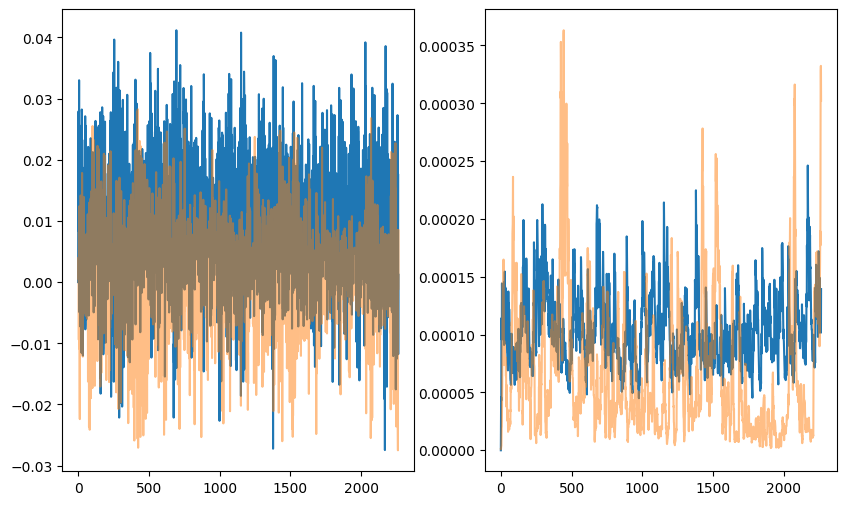

In [90]:
hnmodel = HNGARCH()
params = {
            'omega': 0.000001,  # Constant term
            'alpha': 0.00001,  # ARCH parameter (coefficient for epsilon^2)
            'beta': 0.9,  # GARCH parameter (coefficient for previous variance)
            'lambda': 1,
            'gamma': 0.001
        }
hnmodel.initialize_params() 
hnmodel.set_params(params) 
# data_hn, hn = hnmodel.simulate(params)
result = hnmodel.fit(log_returns)
print(result.x)
pred_data, pred_h = hnmodel.simulate(n=log_returns.shape[0])
fig, ax = plt.subplots(1,2,figsize=(10,6))
ax[0].plot(pred_data)
ax[0].plot(log_returns,alpha=0.5)
ax[1].plot(pred_h)
ax[1].plot(realized_variance,alpha=0.5)

In [105]:
hnmodel.get_params()

{'omega': 1e-06, 'alpha': 1e-05, 'beta': 0.9, 'lambda': 1.0, 'gamma': 0.001}

Kolmogorov-Smirnov Test Statistic: 0.48809591326275903, p-value: 0.0
Jarque-Bera Test Statistic: 53.259946029361984, p-value: 2.721132356594763e-12
Anderson-Darling Test Statistic: 3.550066988031631
Critical Values: [0.575 0.655 0.786 0.916 1.09 ]
Significance Levels: [15.  10.   5.   2.5  1. ]
Shapiro-Wilk Test Statistic: 0.9930881857872009, p-value: 7.458094586354491e-09


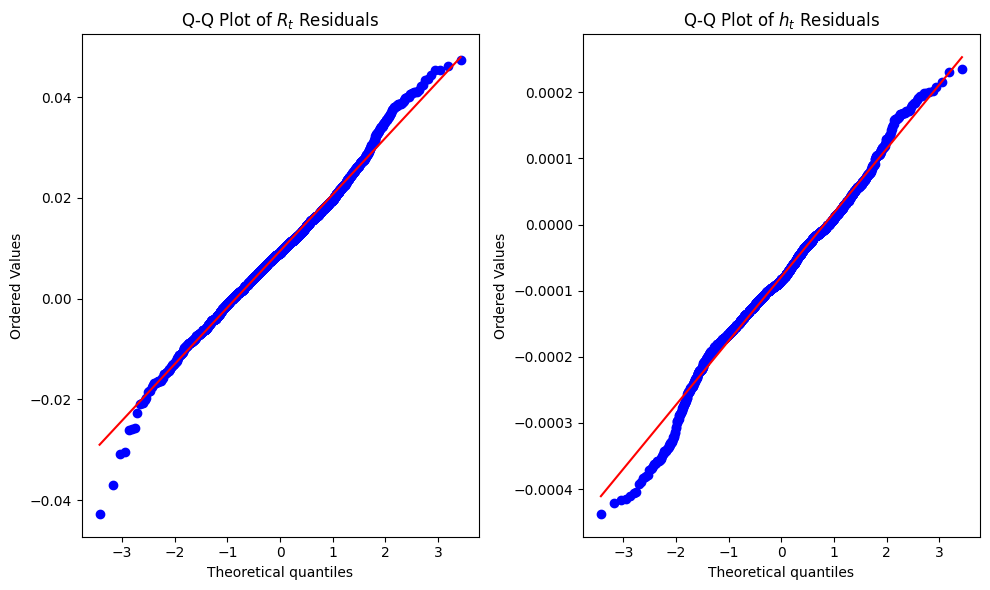

In [104]:
import scipy.stats as stats
data = log_returns
model_name = "HNGARCH"
fig, ax = plt.subplots(1,2, figsize=(10,6))
stats.probplot(pred_data-data, dist="norm", plot=ax[0])
stats.probplot(pred_h-realized_variance, dist="norm", plot=ax[1])
ax[1].set_title(r'Q-Q Plot of $h_t$ Residuals')
ax[0].set_title(r'Q-Q Plot of $R_t$ Residuals')
plt.tight_layout()
# plt.show()
plt.savefig(f"{model_name}_qqplot.png")
residuals = pred_data - data
from scipy.stats import kstest, jarque_bera, anderson, shapiro
stat, p_value = kstest(residuals, 'norm')
print(f"Kolmogorov-Smirnov Test Statistic: {stat}, p-value: {p_value}")
stat, p_value = jarque_bera(residuals)
print(f"Jarque-Bera Test Statistic: {stat}, p-value: {p_value}")
result = anderson(residuals, dist='norm')
print(f"Anderson-Darling Test Statistic: {result.statistic}")
print("Critical Values:", result.critical_values)
print("Significance Levels:", result.significance_level)
stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test Statistic: {stat}, p-value: {p_value}")

The advantage of HN-GARCH is that we are granted a closed-form solution of the dynamics. In particular, the price of the VIX futures at time $t$ with maturity $T-t$ is given by
$\begin{equation}    
\begin{align}
F(t,T) = \mathbb{E}^Q_t(\text{VIX}_t)
&=\mathbb{E}^Q_t (100\sqrt{a+bh_{T+1}})\\
&=\frac{100}{2\sqrt{\pi}}\int^\infty_0\frac{1-e^{-sa}\mathbb{E}^Q_t(e^{-sbh_{T+1}})}{s^{3/2}}ds
\end{align}
\end{equation}$
Also, it can be shown that the moment generating function f of $h_{t+m}$ at time $t$ has the following expression
$\begin{equation}
f(\phi,m,h_{t+1})=\mathbb{E}^Q_t(e^{\phi h_{t+m+1}})
=\exp(C(\phi,m)+H(\phi,m)h_{t+1}),
\end{equation}$
where 
$$
\begin{align}
    C(\phi,n+1)&=C(\phi,n)-\frac{1}{2}\ln(1-2\alpha H(\phi,n))+\omega H(\phi,n)\\
    H(\phi,n+1)&= \frac{\alpha\gamma^* H(\phi,n)}{1-2\alpha H(\phi,n)}+\beta H(\phi,n)
\end{align}
$$
with the initial conditions
$$
C(\phi,0) = 0 \text{ and } H(\phi,0)=\phi.
$$
Then, the VIX futures price under HN-GARCH model can be obtained by
$\begin{equation}
    F(t,T)=\frac{100}{2\sqrt{\pi}}\int^\infty_0\frac{1-e^{-sa}f(-sb,T-t,\frac{(\text{VIX}_t/100)^2-a}{b})}{s^{3/2}}ds
\end{equation}$

## Component GARCH

One limitation of HNGARCH lies in the single variance assumption, limiting the expression power of the model. One particular extension is to further model the long-run variance term $\overline{h_t}$, resulting in the Long-short run component GARCH.
$\begin{equation}
\begin{align}
    R_{t+1} &= r + \left(\lambda - \frac{1}{2} \right)h_{t+1} + \sqrt{h_{t+1}}\epsilon_{t+1},\\
    h_{t+1} &= q_{t+1} + \beta_s (h_{t}-q_{t}) + \alpha_s v_{1,t+1},\\
    q_{t+1} &= \sigma^2 + \beta_q (q_{t}-\sigma^2) + \alpha_q v_{2,t+1}, 
\end{align}
\end{equation}$
where 
$\begin{align}
    v_{i,t+1} = \left((\epsilon_{t+1}-\gamma_i \sqrt{h_{t}})^2 + (1-\gamma_i^2 h_{t})\right) \text{ for }i=1,2.
\end{align}$

From the following figure, we can see that in LSGARCH, the short-run variance $h_t-q_t$ indeed appears to be mean-zero, while the long-run variance $q_t$ captures larger variation.
  

<center><img src="variances.png"></center>

The risk neutralization correspondingly updates to be 
$\begin{equation}
    \begin{aligned}
    R_{t+1} &= r_{t+1} -\frac{1}{2}h_{t} + \sqrt{h_t} \epsilon_t^*\\
        h_{t+1} &= q_{t+1} + \widetilde{\beta}_s(h_t - q_t) + \alpha_s v^*_{1,t+1}\\
        q_{t+1} &= \widetilde{\sigma}^2 + \widetilde{\beta}_q(q_{t} - \widetilde{\sigma}^2) + \alpha_q v^*_{2,t+1}
    \end{aligned}
\end{equation}$
where for $i=1,2$,
$\begin{align} 
\gamma^*_i&=\lambda+\gamma_i\\
\epsilon^*_t &= \epsilon_t + \sqrt{\lambda}h_t\\
v^*_{i,t+1} &= [(\epsilon^*_t-\gamma_i^*\sqrt{h_t})^2-(1+(\gamma_i^*)^2 h_t)]\\
\widetilde{\beta}_s &= \beta + \alpha_s((\gamma_1^*)^2-\gamma_1^2)+ \alpha_q((\gamma_2^*)^2-\gamma_2^2),\\
\widetilde{\beta}_q^* &= \beta_q + \alpha_s((\gamma_1^*)^2-\gamma_1^2)+ \alpha_q((\gamma_2^*)^2-\gamma_2^2),\\
\widetilde{\sigma}^2&=\frac{1-\beta_q}{1-\beta_q^*}\sigma^2.
\end{align}$

Parameters initialized: {'lambda': 1, 'sigma2': 0.003, 'alpha_s': 1e-07, 'beta_s': 0.7, 'gamma_s': 1, 'alpha_q': 1e-07, 'beta_q': 0.8, 'gamma_q': 1}
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6286.376583851101
            Iterations: 5
            Function evaluations: 9
            Gradient evaluations: 1


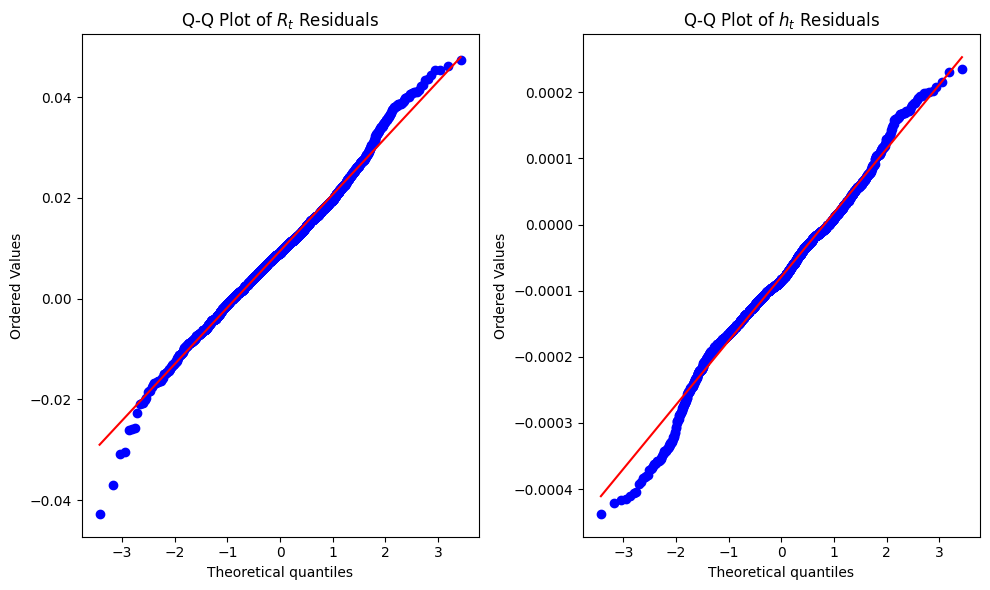

In [101]:
params = {
    'lambda': 0.3,  # Constraint 5: lambda should be small for feasibility
    'sigma2': 0.8e-6,  # Constraint 4: sigma^2 < 1 - beta_q
    'alpha_s': 1e-6, # Constraint 2: alpha_s * gamma_s^2 should be small
    'beta_s': 0.75,  # Constraint 1: beta_s < beta_q
    'gamma_s': 450, # Constraint 2: Keep gamma_s within bounds
    'alpha_q': 7e-6, # Constraint 5: alpha_q * (1 + lambda^2) should be small
    'beta_q': 0.99,  # Constraint 3: beta_q < 1
    'gamma_q': 60, # Constraint 3: Keep gamma_q within bounds
}
new_model = ComponentGARCH()
new_model.initialize_params()
new_model.set_params(params)
result = new_model.fit(log_returns)
pred_data, pred_h, pred_q = new_model.simulate(n=log_returns.shape[0], h0=std_lr, current=mean_lr)
new_model.check_feasibilty(list(new_model.get_params().values()))
con1 = lambda params: params[6] - params[3] - params[2]*params[4]**2 
fig, ax = plt.subplots(1,2, figsize=(10,6))
stats.probplot(pred_data-log_returns, dist="norm", plot=ax[0])
stats.probplot(pred_h-realized_variance, dist="norm", plot=ax[1])
ax[1].set_title(r'Q-Q Plot of $h_t$ Residuals')
ax[0].set_title(r'Q-Q Plot of $R_t$ Residuals')
plt.tight_layout()
# plt.show()
plt.savefig(f"LSGARCH_qqplot.png")

In [107]:
new_model.get_params()

{'lambda': 0.3,
 'sigma2': 8e-07,
 'alpha_s': 1e-06,
 'beta_s': 0.75,
 'gamma_s': 450.0,
 'alpha_q': 7e-06,
 'beta_q': 0.99,
 'gamma_q': 60.0}

In [102]:
residual = pred_data-log_returns
from scipy.stats import kstest, jarque_bera, anderson, shapiro
stat, p_value = kstest(residuals, 'norm')
print(f"Kolmogorov-Smirnov Test Statistic: {stat}, p-value: {p_value}")
stat, p_value = jarque_bera(residuals)
print(f"Jarque-Bera Test Statistic: {stat}, p-value: {p_value}")
result = anderson(residuals, dist='norm')
print(f"Anderson-Darling Test Statistic: {result.statistic}")
print("Critical Values:", result.critical_values)
print("Significance Levels:", result.significance_level)
stat, p_value = shapiro(residuals)
print(f"Shapiro-Wilk Test Statistic: {stat}, p-value: {p_value}")

Kolmogorov-Smirnov Test Statistic: 0.4877646812188056, p-value: 0.0
Jarque-Bera Test Statistic: 0.09311881619195367, p-value: 0.9545078533913893
Anderson-Darling Test Statistic: 0.5316671344025963
Critical Values: [0.575 0.655 0.786 0.916 1.09 ]
Significance Levels: [15.  10.   5.   2.5  1. ]
Shapiro-Wilk Test Statistic: 0.9992493391036987, p-value: 0.5039828419685364


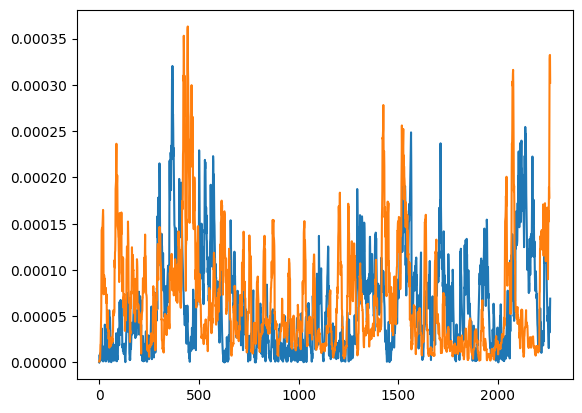

In [80]:
fig, ax =plt.subplots()
ax.plot(np.abs(pred_h))
ax.plot(realized_variance)


the VIX futures price can be expressed as
$\begin{equation}    
\begin{aligned}
F(t,T) &= \mathbb{E}^Q_t(\text{VIX}_t)
=\mathbb{E}^Q_t (100\sqrt{a+b_1 (h_{T+1}-q_{T+1})+b_2 q_{T+1}})\\
&=\frac{100}{2\sqrt{\pi}}\int^\infty_0\frac{1-e^{-sa}f_{s,q}(-b_s x, -b_q x, T-t )}{x^{3/2}}dx,
\end{aligned}
\end{equation}$
where $a = 252 \times (1-\Gamma_q(n))\sigma^{*2}$ and $b_j = 252 \times \Gamma_{j}(n)$, $j=s,q$.
The key is to express the risk neutral conditional expectation using the moment generating function $f$ of the two variances $(h_{t+1} - q_{t+1})$ and $q_{t+1}$. This moment generating function $f$ has a semi-analytic form:
$$
f_{s,q}(\phi_s, \phi_q, m) = e^{A_m(\phi_s, \phi_q)+ B_m(\phi_s, \phi_q)(h_{t+1} - q_{t+1}) + C_m(\phi_s, \phi_q)q_{t+1}}
$$
where \( A_m(\phi_s, \phi_q) \), \( B_m(\phi_s, \phi_q) \), and \( C_m(\phi_s, \phi_q) \) satisfy the following iterative relationship:
$$
\begin{aligned}
A_{m+1}(\phi_s, \phi_q) &= A_m(\phi_s, \phi_q) + \sigma^2 (1 - \beta_q^*) C_m(\phi_s, \phi_q) \\
&
-\frac{1}{2} \left[\ln\left(1 - 2(\alpha_s B_m(\phi_s, \phi_q) + \alpha_q C_m(\phi_s, \phi_q))\right]\right.\\
&- \left.(\alpha_s B_m(\phi_s, \phi_q) + \alpha_q C_m(\phi_s, \phi_q))\right.,\\
B_{m+1}(\phi_s, \phi_q) &= B_m(\phi_s, \phi_q) \beta_s^* 
+ \frac{2(\alpha_s \gamma_s^* B_m(\phi_s, \phi_q) + 2\alpha_q \gamma_q^* C_m(\phi_s, \phi_q))^2}
{1 - 2[\alpha_s B_m(\phi_s, \phi_q) + \alpha_q C_m(\phi_s, \phi_q)]},\\
C_{m+1}(\phi_s, \phi_q) &= C_m(\phi_s, \phi_q) \beta_q^* 
+ \frac{2(\alpha_s \gamma_s^* B_m(\phi_s, \phi_q) + 2\alpha_q \gamma_q^* C_m(\phi_s, \phi_q))^2}
{1 - 2[\alpha_s B_m(\phi_s, \phi_q) + \alpha_q C_m(\phi_s, \phi_q)]}.
\end{aligned}
$$

The initial conditions are given by:
$$
A_0(\phi_s, \phi_q) = 0, \quad B_0(\phi_s, \phi_q) = \phi_s, \quad C_0(\phi_s, \phi_q) = \phi_q.
$$

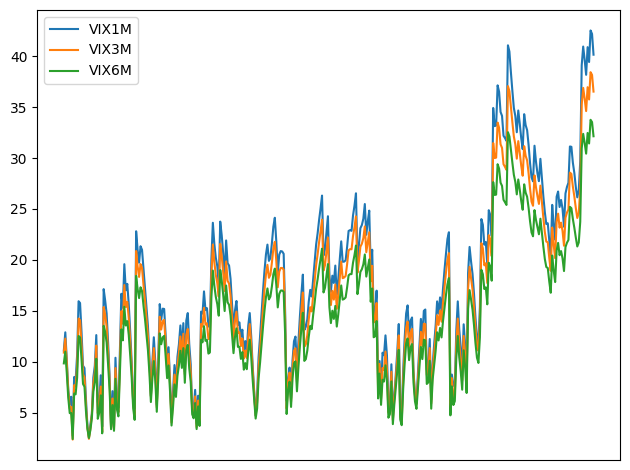

In [81]:
vix1, vix3, vix5 = [] ,[] ,[]
for t in range(360):
    vix1.append(new_model.get_vix(n=22,t=t))
    vix3.append(new_model.get_vix(n=63,t=t))
    vix5.append(new_model.get_vix(n=126,t=t))
vix1 = np.array(vix1)
vix3 = np.array(vix3)
vix5 = np.array(vix5)
plt.plot(vix1*2)
plt.plot(vix3*2)
plt.plot(vix5*2)
plt.xticks([])
plt.legend(['VIX1M', 'VIX3M', 'VIX6M'])
plt.tight_layout()
plt.savefig('vixm.png')
